# House Price Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving fetch_california_housing.xlsx to fetch_california_housing.xlsx


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import os
import pickle
import warnings

In [5]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

In [6]:
df = pd.DataFrame(data.data, columns=data.feature_names)

df['MedHouseVal'] = data.target

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [8]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [9]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
14336,1.5909,44.0,2.733624,1.117904,572.0,2.497817,32.72,-117.17,2.625
10322,7.0592,16.0,7.434579,1.002336,1663.0,3.885514,33.87,-117.76,2.882
14991,3.5861,38.0,5.127625,0.978998,1557.0,2.515347,32.73,-117.03,1.236
11944,4.5122,36.0,6.379679,1.058824,1176.0,3.144385,33.93,-117.43,1.133
8513,4.1458,35.0,5.141487,1.014388,1192.0,2.858513,33.89,-118.31,2.315


In [10]:
rows, cols = df.shape

print(rows)
print(cols)

20640
9


In [11]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [12]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Visualize Data Distribution

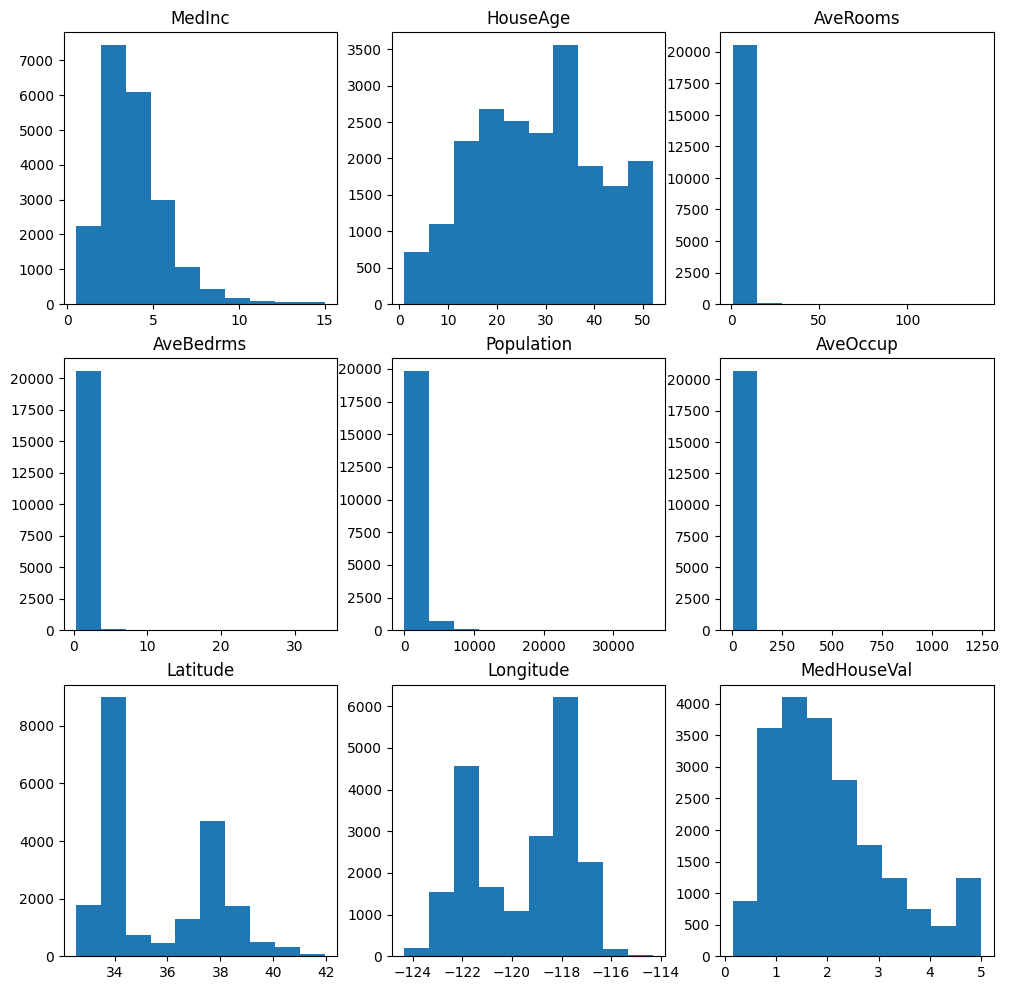

In [13]:
plt.figure(figsize=(12,12))

for i in range(len(df.columns)):
    plt.subplot(3,3,i+1)
    plt.hist(df[df.columns[i]])
    plt.title(df.columns[i])

plt.show()

## Correlation Heatmap

<Axes: >

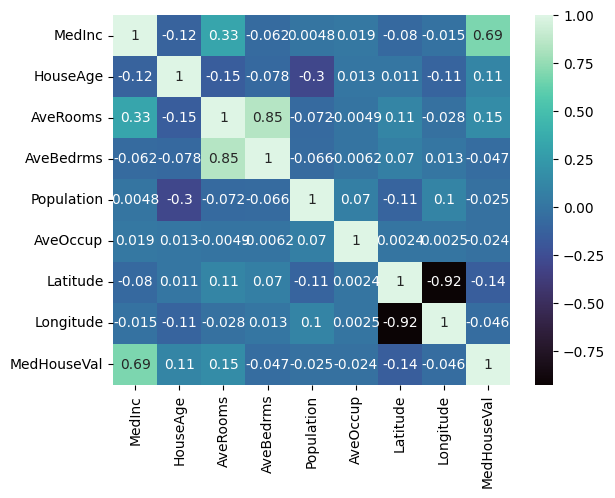

In [14]:
sns.heatmap(df.corr(), annot=True, cmap='mako')

## Separate Features and Target

In [15]:
X = df.drop('MedHouseVal', axis=1)

In [16]:
y = df['MedHouseVal']

## Scale the Data
* Converts all feature values between: 0 to 1
* Improves model performance

In [17]:
scaler = MinMaxScaler()

scaled_X = scaler.fit_transform(X)

## Split Data into Train and Test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X,
    y,
    test_size=0.1,
    random_state=32
)

## Create Machine Learning Model

In [19]:
model = LinearRegression()

## Train the Model

In [20]:
model.fit(X_train, y_train)

LinearRegression()

## Predict House Prices

In [21]:
y_pred = model.predict(X_test)

## Compare Actual vs Predicted Values

In [22]:
compare_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(compare_df)

        Actual  Predicted
20038  0.52300   0.613382
17684  0.87500   1.675474
9720   2.53800   2.558698
17295  5.00001   4.498908
18736  0.98100   0.979259
...        ...        ...
12779  0.49800   0.800351
12771  0.67000   0.828250
15974  2.41900   2.782147
5100   1.42600   2.265050
10873  1.55200   2.003744

[2064 rows x 2 columns]


## Evaluate the Model

In [23]:
score = model.score(X_test, y_test)

print(score)

0.6069178179183773


In [24]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = root_mean_squared_error(y_test, y_pred)

In [25]:
matrix_dict = {'Model Number': [], 'Model':[], 'Model Score':[], 'Mean Absolute Error':[], 'Mean Squared Error':[], 'Root Mean Squared Error':[]}

In [26]:
for i in range(5000):
  X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size = 0.1, random_state = i)
  model = LinearRegression()
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  score = model.score(X_test, y_test)
  mae = mean_absolute_error(y_test, y_pred)
  mse = mean_squared_error(y_test, y_pred)
  rmse = root_mean_squared_error(y_test, y_pred)

  matrix_dict['Model Number'].append(i)
  matrix_dict['Model'].append(model)
  matrix_dict['Model Score'].append(score)
  matrix_dict['Mean Absolute Error'].append(mae)
  matrix_dict['Mean Squared Error'].append(mse)
  matrix_dict['Root Mean Squared Error'].append(rmse)
  print(f'{i} Model Done')
  display(clear = True)
matrix_df = pd.DataFrame(matrix_dict)
matrix_df

,Model Number,Model,Model Score,Mean Absolute Error,Mean Squared Error,Root Mean Squared Error
0,0,LinearRegression(),0.609803,0.534931,0.536252,0.732292
1,1,LinearRegression(),0.600778,0.533055,0.536848,0.732699
2,2,LinearRegression(),0.594513,0.541562,0.545080,0.738295
3,3,LinearRegression(),0.632095,0.515434,0.495734,0.704084
4,4,LinearRegression(),0.590596,0.535983,0.515037,0.717661
...,...,...,...,...,...,...
4995,4995,LinearRegression(),0.567180,0.538414,0.557216,0.746469
4996,4996,LinearRegression(),0.579242,0.536505,0.583962,0.764174
4997,4997,LinearRegression(),0.588020,0.531528,0.552130,0.743055
4998,4998,LinearRegression(),0.571894,0.521472,0.542994,0.736881


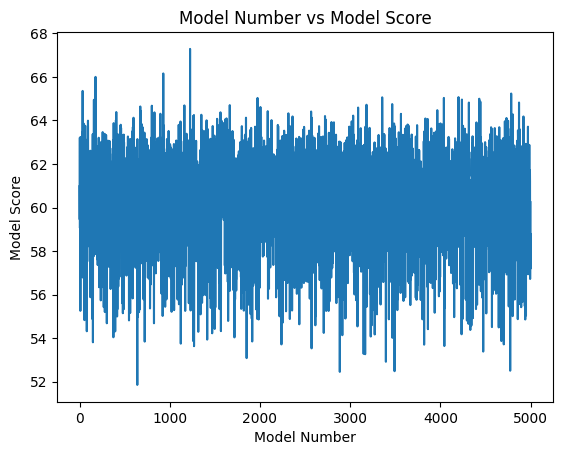

In [27]:
matrix_df['Model Score'].max()

matrix_df['Model Score'].min()

final_model_df = matrix_df[matrix_df['Model Score'] == matrix_df['Model Score'].max()]

matrix_positive_df = matrix_df[matrix_df['Model Score'] >= 0.50]

plt.plot(matrix_positive_df['Model Number'], matrix_positive_df['Model Score']* 100)
plt.xlabel('Model Number')
plt.ylabel('Model Score')
plt.title('Model Number vs Model Score')
plt.show()

In [28]:
final_model = final_model_df['Model']

# Get the actual LinearRegression model from the DataFrame
final_model = final_model_df['Model'].values[0]  # pick the first/best model

# Save the actual model
with open('Model_For_House_Price_Prediction.pkl', 'wb') as f:
    pickle.dump(final_model, f)

print("Model Saved Successfully")

# Save the fitted scaler to use in Streamlit app
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Model Saved Successfully


In [29]:
with open("Model_For_House_Price_Prediction.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>


In [30]:
print(final_model)

LinearRegression()


In [31]:
from google.colab import files

files.download('Model_For_House_Price_Prediction.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>